<a href="https://colab.research.google.com/github/Ziqi-Li/GEO4162C/blob/fall-24/notebooks/Spatial_optimization_p_median.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Spatial Optimization (1): p-Median  Problem

This problem entails the location of p-facilities while minimizing the total weighted distance of servicing all demands.
Each node has an associated weight that represents the amount of demand at that node.


**Objective function:** Minimizing demand-weighted  summed over all facilities and demand nodes.

**Decision variables:** where to put the facilities and which demand nodes are serviced by which facility location

**Constraints:**
- Each node is serviced by 1 facility
- A node can be serviced by a facility at a certain location only if there is a facility.
- We must place p facilities
- Each node is either a facility or not.

In [1]:
pip install -q pulp

In [2]:
from pulp import *
import numpy as np
import geopandas as gpd
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [3]:
#read a sample shapefile
fl_counties = gpd.read_file("https://raw.githubusercontent.com/Ziqi-Li/GEO4162C/refs/heads/fall-24/data/fl_pop.geojson")

In [4]:
fl_counties.shape

(67, 24)

In [5]:
#create a demand and a facilities variable, indicating the indices of each demand and facility.
#demand node: all counties
#facility: Facilities will be built on top of some chosen counties

n = fl_counties.shape[0]

demand = np.arange(0,n,1)
facilities = np.arange(0,n,1)

In [6]:
#Calculate a distance matrix d_ij (n by n)
coords = list(zip(fl_counties.centroid.x,fl_counties.centroid.y))

d = cdist(coords,coords)

<ipython-input-6-9b7359aaee9c>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = list(zip(fl_counties.centroid.x,fl_counties.centroid.y))


In [7]:
#the demand for each county (h_i) is the total populatoion
h = fl_counties.total_population.values

In [8]:
# declare facilities variables;the resulting variable names are: X_1,X_2,...
X = LpVariable.dicts('X_%s',(facilities),cat='Binary')

# declare demand-facility pair variables; the resulting variable names are Y_0_1, Y_0_2,...
Y = LpVariable.dicts('Y_%s_%s', (demand,facilities),cat='Binary')

In [9]:
#Number of facilities to place now p = 3
p = 3 #change this and re-run the code.

#Create a new problem
prob = LpProblem('P_Median', LpMinimize)

In [10]:
# Objective function: Minimizing weighted demand-distance  summed over all facilities and demand nodes
# (h_i: demand at i; d_ij: distance between i and j)
# A "for" loop is used for iterating over a sequence

prob += sum(sum(h[i] * d[i][j] * Y[i][j] for j in facilities) for i in demand)

In [11]:
# This constraint indicates we must place exactly p facilities

prob += sum([X[j] for j in facilities]) == p

In [12]:
# This constraint implies that a demand node i can only be serviced by one facility

for i in demand:
    prob += sum(Y[i][j] for j in facilities) == 1

In [13]:
# This constraint implies that that demand node i
# can be serviced by a facility at j only if there is a facility at j
# It implicitly removes situation when X[j] = 0 but Y[i][j] = 1
# (node i is served by j but there is no facility at j)

for i in demand:
    for j in facilities:
        prob +=  Y[i][j] <= X[j]

In [14]:
%%time

# Solve the above problem
prob.solve()

print("Status:", LpStatus[prob.status])

Status: Optimal
CPU times: user 193 ms, sys: 8.21 ms, total: 202 ms
Wall time: 2.02 s


In [15]:
# The minimized total demand-distance. The unit is person * meter (total distance travelled)
print("Objective: ",value(prob.objective))

Objective:  17676577.722609613


In [16]:
# Print the facility node.
rslt=[]
for v in prob.variables():
    subV = v.name.split('_')

    if subV[0] == "X" and v.varValue == 1:
        rslt.append(int(subV[1]))
        print('Facility Node: ', subV[1])

Facility Node:  12
Facility Node:  3
Facility Node:  40


In [17]:
# Get the geomerty of the facility nodes.
facility_nodes = fl_counties.iloc[rslt,:]

In [18]:
facility_nodes

,STATEFP10,COUNTYFP10,COUNTYNS10,GEOID10,NAME10,NAMELSAD10,LSAD10,CLASSFP10,MTFCC10,CSAFP10,...,AWATER10,INTPTLAT10,INTPTLON10,NAME,total_population,monthly_housing_costs,population_drive_to_work,state,county,geometry
12,12,069,00308551,12069,Lake,Lake County,06,H1,G4020,422,...,566126522,+28.7641128,-081.7122822,"Lake County, Florida",345867.0,913.0,131273.0,12,069,"POLYGON ((-81.62473 28.78593, -81.6249 28.7859..."
3,12,011,00295753,12011,Broward,Broward County,06,H1,G4020,None,...,292869341,+26.1935200,-080.4766578,"Broward County, Florida",1926205.0,1356.0,898752.0,12,011,"POLYGON ((-80.29694 26.33436, -80.29691 26.335..."
40,12,131,00295727,12131,Walton,Walton County,06,H1,G4020,None,...,523099633,+30.6312106,-086.1766139,"Walton County, Florida",68262.0,953.0,27226.0,12,131,"POLYGON ((-86.39538 30.43334, -86.39537 30.433..."


<ipython-input-19-5fb801abde6b>:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fl_counties.centroid.plot(ax=ax,markersize=fl_counties.total_population/1000)#markersize is proportional to the population
<ipython-input-19-5fb801abde6b>:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  facility_nodes.centroid.plot(ax=ax,color="red",markersize=300,marker="*")


<Axes: >

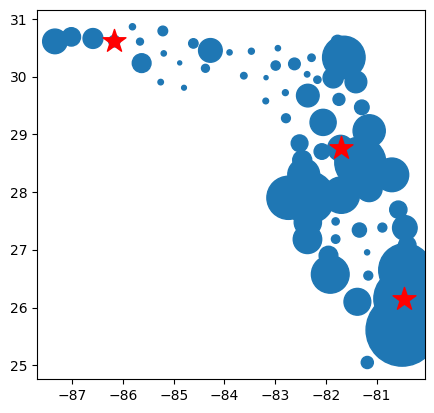

In [19]:
#Plot the faclities (stars) on top of the demand map.
fig, ax = plt.subplots(figsize=(5,5))

fl_counties.centroid.plot(ax=ax,markersize=fl_counties.total_population/1000)#markersize is proportional to the population
facility_nodes.centroid.plot(ax=ax,color="red",markersize=300,marker="*")